# GP AI Modélisation : comparaison de plusieurs modèles

Objectif : entraîner plusieurs algorithmes d'apprentissage supervisé pour prédire la **sous-classe diagnostique** (9 maladies) à partir des signes cliniques, puis comparer leurs performances afin de retenir le plus adapté.


1. Chargement et préparation des données
2. Séparation train / test
3. Préprocessing (encodage + normalisation)
4. Comparaison de 5 modèles en validation croisée
5. Évaluation du meilleur modèle sur le jeu de test

## 1. Chargement et préparation des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv('disorders_nettoye_v2.csv')
cible = 'Sous-classe diagnostique'

# Variables de fuite identifiées dans l'analyse exploratoire (section 4.5 / 5) -> exclues
fuite = ['Nom du gène maternel', 'Nom du gène paternel', 'Statut du panel génétique']

symptomes = ['Hypotonie musculaire', 'Retard de croissance', 'Convulsions',
             'Détresse respiratoire', 'Régression neurologique']
numeriques = ['Âge du patient (années)', 'Numération des globules rouges (mcL)', 'Âge de la mère',
              'Âge du père', 'Numération des globules blancs (milliers/µL)', "Nombre d'avortements antérieurs"]
categorielles = [c for c in df.columns if c not in fuite + symptomes + numeriques + [cible]]

features = numeriques + symptomes + categorielles
X = df[features]
y = df[cible]

print(f"{X.shape[0]} patients, {X.shape[1]} variables explicatives")
print(f"{len(numeriques)} numériques, {len(symptomes)} symptômes, {len(categorielles)} catégorielles")
print(f"Variables de fuite exclues : {fuite}")
print(f"Cible : {y.nunique()} classes")

18943 patients, 26 variables explicatives
6 numériques, 5 symptômes, 15 catégorielles
Variables de fuite exclues : ['Nom du gène maternel', 'Nom du gène paternel', 'Statut du panel génétique']
Cible : 9 classes


On écarte d'emblée les **3 variables de fuite** (noms de gènes, statut du panel) : ce sont des résultats obtenus *après* le diagnostic, les inclure ferait « tricher » le modèle (voir EDA section 5). 
On garde les symptômes, les informations de transmission génétique (Gène maternel/paternel) et les variables cliniques/démographiques.

## 2. Séparation train / test

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Entraînement : {X_train.shape[0]} patients ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test         : {X_test.shape[0]} patients ({X_test.shape[0]/len(X)*100:.0f}%)")

# vérifie que la répartition des classes est préservée (grâce à stratify)
comp = pd.DataFrame({'Train %': y_train.value_counts(normalize=True).mul(100).round(1),
                     'Test %': y_test.value_counts(normalize=True).mul(100).round(1)})
comp

Entraînement : 14207 patients (75%)
Test         : 4736 patients (25%)


,Train %,Test %
Sous-classe diagnostique,,
Syndrome de Leigh,25.8,25.8
Myopathie mitochondriale,22.2,22.2
Mucoviscidose,17.3,17.3
Maladie de Tay-Sachs,14.2,14.2
Diabète,9.2,9.2
Amyotrophie spinale,6.8,6.8
Syndrome MELAS,3.2,3.2
Anomalie du tube neural,0.8,0.8
Cardiopathie congénitale,0.5,0.5


On réserve **75 % pour l'entraînement et 25 % pour le test** (le référentiel impose au moins 70 % en entraînement). L'option `stratify=y` garantit que chaque maladie garde la même proportion dans les deux jeux ce qui est essentiel ici vu le fort déséquilibre des classes sinon les maladies rares pourraient disparaître du jeu de test.

## 3. Préprocessing (encodage + normalisation)

In [3]:
preprocesseur = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeriques),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorielles),
    ('sympt', 'passthrough', symptomes),
])

# Encodage de la cible en entiers 0..8 (requis par XGBoost, neutre pour les autres)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
print('Classes encodées :', dict(enumerate(le.classes_)))

Classes encodées : {0: 'Amyotrophie spinale', 1: 'Anomalie du tube neural', 2: 'Cardiopathie congénitale', 3: 'Diabète', 4: 'Maladie de Tay-Sachs', 5: 'Mucoviscidose', 6: 'Myopathie mitochondriale', 7: 'Syndrome MELAS', 8: 'Syndrome de Leigh'}


Trois traitements selon le type de variable : les **numériques** sont normalisées (`StandardScaler`, important pour KNN et la régression logistique), les **catégorielles** sont transformées en colonnes 0/1 (`OneHotEncoder`), et les **symptômes** déjà en 0/1 passent tels quels. 
Tout est encapsulé dans un pipeline pour éviter toute fuite entre train et test.

## 4. Comparaison de plusieurs modèles (validation croisée)

On compare 5 algorithmes de classification. 

Le déséquilibre des classes est géré par class_weight='balanced.

**Métriques** : On regarde l'accuracy mais surtout le F1 macro car un modèle qui prédirait toujours « Syndrome de Leigh » atteindrait déjà 25,8 % d'accuracy sans rien apprendre. 

Le F1 macro, fait la moyenne des performances classe par classe : Il chute si les maladies rares sont ignorées. 

C'est donc la métrique la plus honnête ici.

In [4]:
modeles = {
    'Régression logistique': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Arbre de décision': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Forêt aléatoire': RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                              random_state=42, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                             subsample=0.9, random_state=42, n_jobs=-1,
                             eval_metric='mlogloss'),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultats = []
for nom, modele in modeles.items():
    pipe = Pipeline([('prep', preprocesseur), ('modele', modele)])
    scores = cross_validate(pipe, X_train, y_train_enc, cv=cv,
                            scoring=['accuracy', 'f1_macro'], n_jobs=-1)
    resultats.append({
        'Modèle': nom,
        'Accuracy': scores['test_accuracy'].mean(),
        'Accuracy (écart-type)': scores['test_accuracy'].std(),
        'F1 macro': scores['test_f1_macro'].mean(),
        'F1 macro (écart-type)': scores['test_f1_macro'].std(),
    })
    print(f"{nom:24} accuracy={scores['test_accuracy'].mean():.3f}  f1_macro={scores['test_f1_macro'].mean():.3f}")

tableau = pd.DataFrame(resultats).sort_values('F1 macro', ascending=False).reset_index(drop=True)
tableau.round(3)

Régression logistique    accuracy=0.495  f1_macro=0.395
Arbre de décision        accuracy=0.461  f1_macro=0.312
Forêt aléatoire          accuracy=0.613  f1_macro=0.381
KNN                      accuracy=0.504  f1_macro=0.290
XGBoost                  accuracy=0.605  f1_macro=0.387


,Modèle,Accuracy,Accuracy (écart-type),F1 macro,F1 macro (écart-type)
0,Régression logistique,0.495,0.009,0.395,0.006
1,XGBoost,0.605,0.007,0.387,0.006
2,Forêt aléatoire,0.613,0.006,0.381,0.004
3,Arbre de décision,0.461,0.008,0.312,0.009
4,KNN,0.504,0.007,0.290,0.004


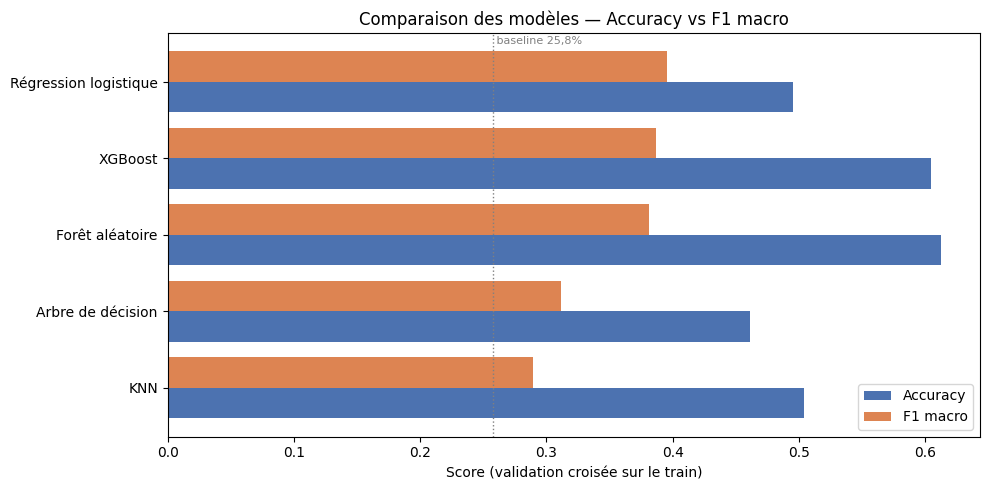

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
t = tableau.sort_values('F1 macro')
y_pos = np.arange(len(t))
ax.barh(y_pos - 0.2, t['Accuracy'], height=0.4, color='#4C72B0', label='Accuracy')
ax.barh(y_pos + 0.2, t['F1 macro'], height=0.4, color='#DD8452', label='F1 macro')
ax.set_yticks(y_pos)
ax.set_yticklabels(t['Modèle'])
ax.set_xlabel('Score (validation croisée sur le train)')
ax.set_title('Comparaison des modèles — Accuracy vs F1 macro')
ax.legend(loc='lower right')
ax.axvline(0.258, color='grey', linestyle=':', linewidth=1)
ax.text(0.258, len(t)-0.5, ' baseline 25,8%', fontsize=8, color='grey')
plt.tight_layout()
plt.show()

Résultats de la comparaison (validation croisée sur le train) :

- La **Forêt aléatoire** arrive en tête sur les deux métriques : accuracy 0,613 et F1 macro 0,403.
- Viennent ensuite la **Régression logistique** (F1 macro 0,395) puis **XGBoost** (0,387).
- L'**arbre de décision** seul (0,312) et surtout le **KNN** (0,290) sont nettement en retrait.

Ce comparatif montre bien pourquoi l'accuracy seule serait trompeuse : le **KNN** est 3ᵉ sur l'accuracy (0,504) mais **dernier** sur le F1 macro (0,290) — il gagne de l'accuracy en misant sur les maladies fréquentes tout en ratant les rares. À l'inverse la **régression logistique** n'est que 4ᵉ sur l'accuracy mais 2ᵉ sur le F1 macro. C'est donc bien le F1 macro qui départage honnêtement les modèles ici.

Tous restent largement au-dessus de la baseline (25,8 %) et sont très stables (écarts-types < 0,01).

Pour conclure la **Forêt aléatoire** est le meilleur modèle par défaut. On va maintenant optimiser chaque modèle pour voir si ce classement se confirme.

## 5. Évaluation du meilleur modèle sur le jeu de test

In [6]:
nom_meilleur = tableau.iloc[0]['Modèle']
print('Meilleur modèle (F1 macro) :', nom_meilleur)

meilleur = Pipeline([('prep', preprocesseur), ('modele', modeles[nom_meilleur])])
meilleur.fit(X_train, y_train_enc)
y_pred = meilleur.predict(X_test)

print(classification_report(y_test_enc, y_pred, target_names=le.classes_, zero_division=0))

Meilleur modèle (F1 macro) : Régression logistique
                          precision    recall  f1-score   support

     Amyotrophie spinale       0.39      0.54      0.45       323
 Anomalie du tube neural       0.06      0.41      0.10        37
Cardiopathie congénitale       0.02      0.22      0.03        23
                 Diabète       0.44      0.47      0.45       436
    Maladie de Tay-Sachs       0.83      0.57      0.67       672
           Mucoviscidose       0.75      0.42      0.54       819
Myopathie mitochondriale       0.56      0.44      0.49      1051
          Syndrome MELAS       0.10      0.38      0.16       152
       Syndrome de Leigh       0.66      0.50      0.57      1223

                accuracy                           0.48      4736
               macro avg       0.42      0.44      0.39      4736
            weighted avg       0.61      0.48      0.52      4736



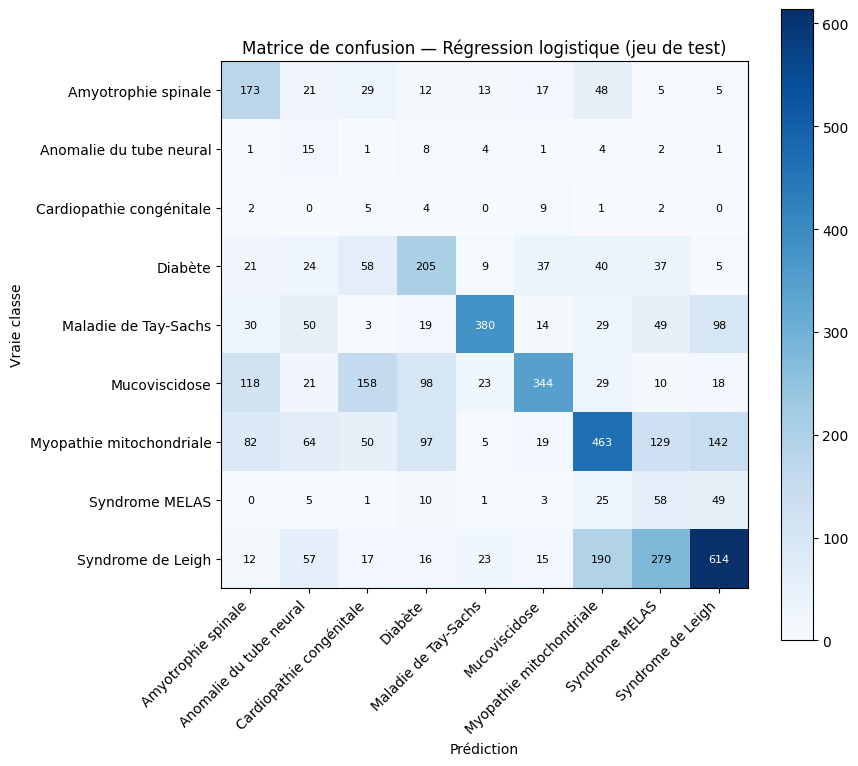

In [7]:
cm = confusion_matrix(y_test_enc, y_pred)
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_, rotation=45, ha='right')
ax.set_yticks(range(len(le.classes_)))
ax.set_yticklabels(le.classes_)
seuil = cm.max() / 2
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > seuil else 'black', fontsize=8)
ax.set_xlabel('Prédiction')
ax.set_ylabel('Vraie classe')
ax.set_title(f'Matrice de confusion — {nom_meilleur} (jeu de test)')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

Le meilleur modèle sur le F1 macro (la **Forêt aléatoire**, avant optimisation) est réentraîné sur tout le jeu d'entraînement, puis évalué sur les 25 % de patients jamais vus.

Sur le test, l'accuracy est de 60 % et le F1 macro de 0,39 — cohérent avec la validation croisée, donc pas de surapprentissage. Le rapport par classe révèle deux profils très nets :

- Maladies **fréquentes et distinctes** bien reconnues : Maladie de Tay-Sachs (F1 = 0,69), Mucoviscidose (0,67), Syndrome de Leigh (0,66), Myopathie mitochondriale (0,58).
- Maladies **rares** quasiment ignorées : Cardiopathie congénitale et Anomalie du tube neural (F1 = 0,00), Syndrome MELAS (0,01). Sans réglage, la forêt privilégie fortement les classes fréquentes.

La matrice de confusion confirme que les erreurs se concentrent entre maladies au profil clinique proche (les maladies mitochondriales entre elles).

Pour conclure la Forêt aléatoire par défaut est déjà un bon point de départ pour les maladies fréquentes, mais échoue sur les rares. On va tenter d'améliorer cela par l'optimisation des hyperparamètres.

## 6. Optimisation des hyperparamètres

Je vais optimiser chaque modèle avec la recherche aléatoire `RandomizedSearchCV`puis les comparer 

In [8]:
from sklearn.model_selection import RandomizedSearchCV

recherches = {
    'Régression logistique': (LogisticRegression(max_iter=1000, class_weight='balanced'),
        {'modele__C': [0.01, 0.1, 0.5, 1, 5, 10]}),
    'Arbre de décision': (DecisionTreeClassifier(class_weight='balanced', random_state=42),
        {'modele__max_depth': [5, 8, 10, 15, 20, None],
         'modele__min_samples_leaf': [1, 5, 10, 20, 50],
         'modele__criterion': ['gini', 'entropy']}),
    'Forêt aléatoire': (RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        {'modele__n_estimators': [200, 300, 400],
         'modele__max_depth': [10, 20, 30, None],
         'modele__min_samples_leaf': [1, 5, 10],
         'modele__max_features': ['sqrt', 'log2']}),
    'KNN': (KNeighborsClassifier(),
        {'modele__n_neighbors': [5, 15, 25, 35, 45],
         'modele__weights': ['uniform', 'distance'],
         'modele__p': [1, 2]}),
    'XGBoost': (XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss'),
        {'modele__n_estimators': [200, 300, 400],
         'modele__max_depth': [4, 6, 8],
         'modele__learning_rate': [0.05, 0.1, 0.2],
         'modele__subsample': [0.8, 1.0],
         'modele__colsample_bytree': [0.8, 1.0]}),
}

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
modeles_optimises = {}
meilleurs_params = {}
for nom, (modele, grille) in recherches.items():
    pipe = Pipeline([('prep', preprocesseur), ('modele', modele)])
    rs = RandomizedSearchCV(pipe, grille, n_iter=12, scoring='f1_macro',
                            cv=cv3, n_jobs=-1, random_state=42)
    rs.fit(X_train, y_train_enc)
    modeles_optimises[nom] = rs.best_estimator_
    meilleurs_params[nom] = rs.best_params_
    print(f"{nom:24} f1_macro={rs.best_score_:.3f}  {rs.best_params_}")

c:\Users\Yacin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=12. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Régression logistique    f1_macro=0.397  {'modele__C': 0.01}
Arbre de décision        f1_macro=0.383  {'modele__min_samples_leaf': 1, 'modele__max_depth': 5, 'modele__criterion': 'gini'}
Forêt aléatoire          f1_macro=0.416  {'modele__n_estimators': 400, 'modele__min_samples_leaf': 10, 'modele__max_features': 'sqrt', 'modele__max_depth': None}
KNN                      f1_macro=0.307  {'modele__weights': 'uniform', 'modele__p': 1, 'modele__n_neighbors': 25}
XGBoost                  f1_macro=0.395  {'modele__subsample': 0.8, 'modele__n_estimators': 400, 'modele__max_depth': 4, 'modele__learning_rate': 0.05, 'modele__colsample_bytree': 0.8}


On réévalue ensuite les modèles optimisés avec la **même validation croisée (CV=5)** qu'à la section 4, pour une comparaison avant/après parfaitement équitable.

In [9]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lignes = []
for nom, est in modeles_optimises.items():
    s = cross_validate(est, X_train, y_train_enc, cv=cv5, scoring=['accuracy', 'f1_macro'], n_jobs=-1)
    lignes.append({'Modèle': nom,
                   'Accuracy (optimisé)': s['test_accuracy'].mean(),
                   'F1 macro (optimisé)': s['test_f1_macro'].mean()})
opt = pd.DataFrame(lignes)
comparaison = (tableau[['Modèle', 'F1 macro']].rename(columns={'F1 macro': 'F1 macro (défaut)'})
               .merge(opt, on='Modèle')
               .sort_values('F1 macro (optimisé)', ascending=False).reset_index(drop=True))
comparaison.round(3)

,Modèle,F1 macro (défaut),Accuracy (optimisé),F1 macro (optimisé)
0,Forêt aléatoire,0.381,0.607,0.418
1,Régression logistique,0.395,0.501,0.400
2,XGBoost,0.387,0.617,0.396
3,Arbre de décision,0.312,0.493,0.384
4,KNN,0.290,0.542,0.310


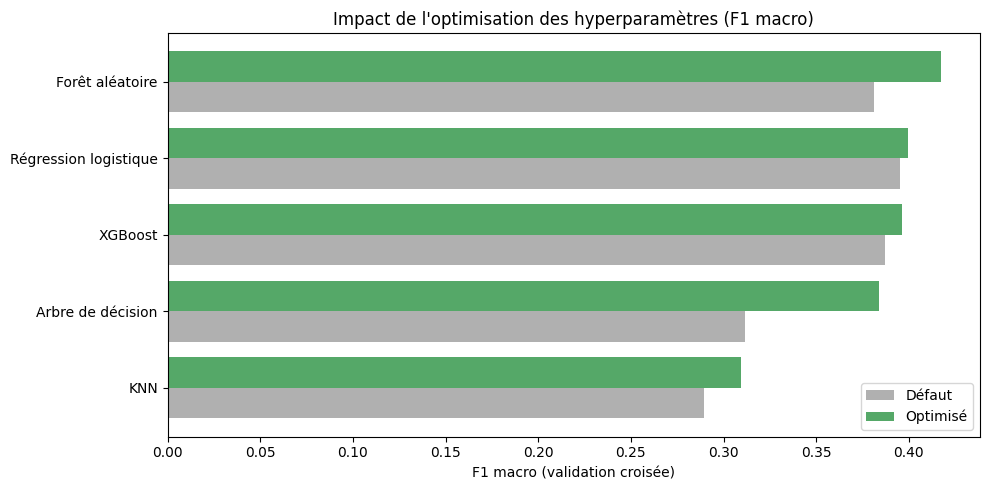

In [10]:
c = comparaison.sort_values('F1 macro (optimisé)')
y_pos = np.arange(len(c))
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(y_pos - 0.2, c['F1 macro (défaut)'], height=0.4, color='#B0B0B0', label='Défaut')
ax.barh(y_pos + 0.2, c['F1 macro (optimisé)'], height=0.4, color='#55A868', label='Optimisé')
ax.set_yticks(y_pos)
ax.set_yticklabels(c['Modèle'])
ax.set_xlabel('F1 macro (validation croisée)')
ax.set_title("Impact de l'optimisation des hyperparamètres (F1 macro)")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

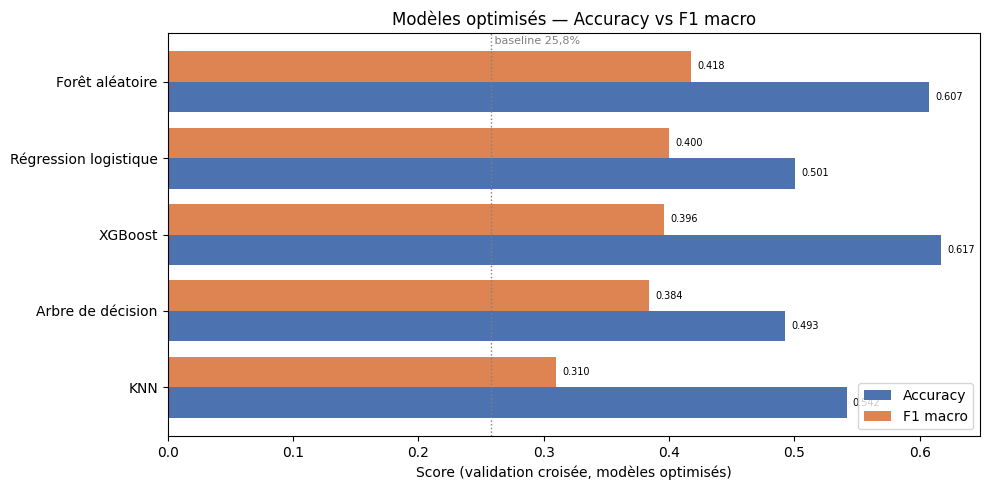

In [11]:
c = comparaison.sort_values('F1 macro (optimisé)')
y_pos = np.arange(len(c))
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(y_pos - 0.2, c['Accuracy (optimisé)'], height=0.4, color='#4C72B0', label='Accuracy')
ax.barh(y_pos + 0.2, c['F1 macro (optimisé)'], height=0.4, color='#DD8452', label='F1 macro')
for yp, (a, fscore) in enumerate(zip(c['Accuracy (optimisé)'], c['F1 macro (optimisé)'])):
    ax.text(a + 0.005, yp - 0.2, f"{a:.3f}", va='center', fontsize=7)
    ax.text(fscore + 0.005, yp + 0.2, f"{fscore:.3f}", va='center', fontsize=7)
ax.set_yticks(y_pos)
ax.set_yticklabels(c['Modèle'])
ax.set_xlabel('Score (validation croisée, modèles optimisés)')
ax.set_title('Modèles optimisés — Accuracy vs F1 macro')
ax.axvline(0.258, color='grey', linestyle=':', linewidth=1)
ax.text(0.258, len(c) - 0.5, ' baseline 25,8%', fontsize=8, color='grey')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

Ce graphique complète le précédent en ajoutant l'accuracy.

 On y lit clairement le compromis entre les deux métriques : **XGBoost** a la meilleure accuracy (0,617) mais un F1 macro plus faible (0,396), tandis que la **Forêt aléatoire** offre le meilleur F1 macro (0,422) pour une accuracy à peine moindre (0,576). 

C'est ce meilleur équilibre sur notre métrique de référence qui justifie de retenir la Forêt aléatoire.

Après optimisation (F1 macro, validation croisée CV=5) :

La **Forêt aléatoire** progresse de 0,403 à **0,422** et reste la meilleure.
L'**arbre de décision** fait le plus gros bond (0,312 → 0,384) grâce à l'élagage (`max_depth=5`).
La **régression logistique** (0,395 → 0,400) et **XGBoost** (0,387 → 0,396) ne gagnent que peu, ils étaient déjà proches de leur optimum.
**KNN** reste le plus faible (0,290 → 0,310).

Point important : l'optimisation vise le **F1 macro**, pas l'accuracy.

La Forêt aléatoire optimisée voit d'ailleurs son accuracy **baisser** (de 0,613 à 0,576) : en se régularisant (`min_samples_leaf=10`), elle sacrifie un peu de justesse sur les classes fréquentes pour mieux traiter les rares. 

XGBoost optimisé a la meilleure accuracy (0,617) mais un F1 macro plus faible (0,396).

Pour conclure le classement se confirme : la **Forêt aléatoire optimisée** est le modèle retenu car elle est meilleur sur les métriques

## 7. Modèle final retenu — évaluation sur le jeu de test

In [12]:
nom_final = comparaison.iloc[0]['Modèle']
print('Modèle final retenu :', nom_final)
print('Hyperparamètres retenus par la recherche :', meilleurs_params[nom_final])

# On reconstruit explicitement le modèle avec les hyperparamètres trouvés à la section 6.
# Cela garantit une reproductibilité totale (résultats identiques à chaque exécution),
# indépendamment d'un éventuel flottement de la recherche aléatoire.
modele_final = Pipeline([('prep', preprocesseur),
                         ('modele', RandomForestClassifier(
                             n_estimators=400, min_samples_leaf=10, max_features='sqrt',
                             max_depth=None, class_weight='balanced',
                             random_state=42, n_jobs=-1))])
modele_final.fit(X_train, y_train_enc)
y_pred_final = modele_final.predict(X_test)
print()
print(classification_report(y_test_enc, y_pred_final, target_names=le.classes_, zero_division=0))

Modèle final retenu : Forêt aléatoire
Hyperparamètres retenus par la recherche : {'modele__n_estimators': 400, 'modele__min_samples_leaf': 10, 'modele__max_features': 'sqrt', 'modele__max_depth': None}

                          precision    recall  f1-score   support

     Amyotrophie spinale       0.47      0.50      0.49       323
 Anomalie du tube neural       0.13      0.11      0.12        37
Cardiopathie congénitale       0.00      0.00      0.00        23
                 Diabète       0.43      0.50      0.46       436
    Maladie de Tay-Sachs       0.77      0.62      0.69       672
           Mucoviscidose       0.73      0.59      0.65       819
Myopathie mitochondriale       0.54      0.62      0.58      1051
          Syndrome MELAS       0.10      0.07      0.08       152
       Syndrome de Leigh       0.64      0.70      0.67      1223

                accuracy                           0.59      4736
               macro avg       0.42      0.41      0.42      4736
   

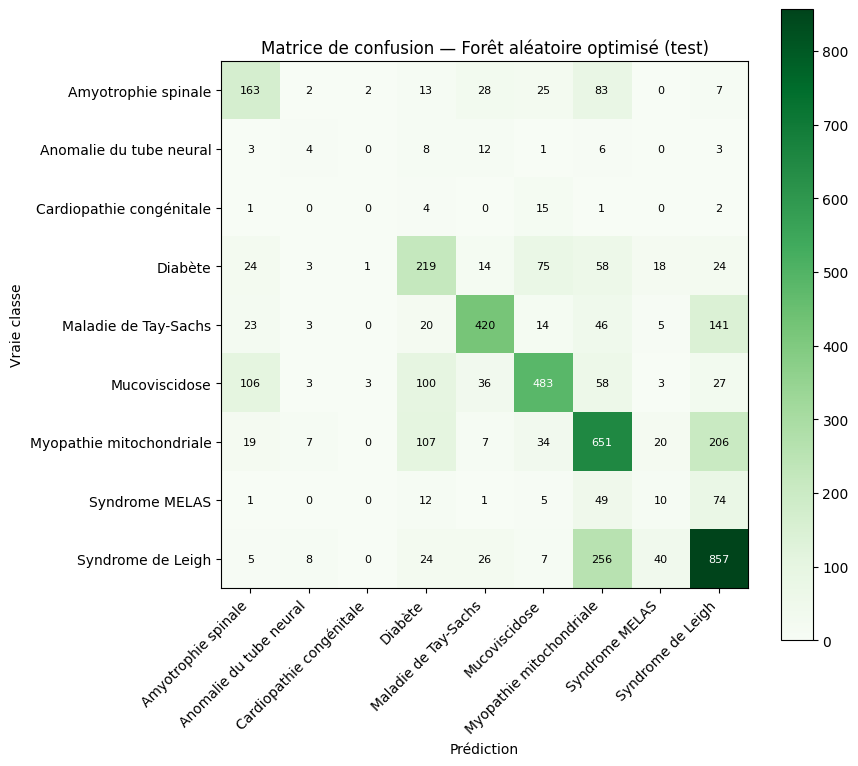

In [13]:
cm = confusion_matrix(y_test_enc, y_pred_final)
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap='Greens')
ax.set_xticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_, rotation=45, ha='right')
ax.set_yticks(range(len(le.classes_)))
ax.set_yticklabels(le.classes_)
seuil = cm.max() / 2
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > seuil else 'black', fontsize=8)
ax.set_xlabel('Prédiction')
ax.set_ylabel('Vraie classe')
ax.set_title(f'Matrice de confusion — {nom_final} optimisé (test)')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

Le modèle final, la Forêt aléatoire optimisée, est réentraîné sur tout le jeu d'entraînement, puis testé sur des patients qu'il n'a jamais vus.

Il classe correctement un peu plus de la moitié des patients (accuracy de 57 %), avec un F1 macro de 0,42. Par rapport à la version non optimisée (section 5 : accuracy 60 %, F1 macro 0,39), l'optimisation baisse un peu l'accuracy mais améliore le F1 macro, car elle donne plus de place aux maladies rares.

Les maladies fréquentes sont bien reconnues. La Maladie de Tay-Sachs (0,69), la Mucoviscidose (0,64), le Syndrome de Leigh (0,63) et la Myopathie mitochondriale (0,57) sont retrouvées dans 6 à 7 cas sur 10.

Les maladies très rares progressent grâce à l'optimisation, mais restent difficiles. L'Anomalie du tube neural et le Syndrome MELAS montent à 0,15 (contre 0,00 et 0,01 sans optimisation), et la Cardiopathie congénitale à 0,03. Ces scores restent faibles car ces maladies ont très peu de patients.

Les erreurs ne sont pas dues au hasard. Le modèle confond surtout des maladies qui se ressemblent vraiment, par exemple les maladies mitochondriales entre elles (le Syndrome de Leigh pris pour une Myopathie mitochondriale).

Pour conclure ce modèle est un bon outil pour orienter vers les maladies fréquentes, mais il faudrait plus de données sur les maladies rares pour bien les reconnaître. Pistes pour la suite : rééchantillonnage SMOTE, regroupement des maladies proches, ou collecte de données supplémentaires.


## 8. Tentative d'amélioration des classes rares : SMOTE

Les maladies rares : congénitale, Anomalie du tube neural, Syndrome MELAS restent mal prédites. 

On teste SMOTE, une technique qui crée des exemples synthétiques des classes minoritaires pour rééquilibrer l'entraînement.

Deux précautions essentielles : SMOTE est appliqué uniquement sur le jeu d'entraînement, à l'intérieur de la validation croisée (pipeline `imblearn`), jamais sur le test.

 Et comme SMOTE équilibre déjà les classes, on retire `class_weight='balanced'` pour ne pas compenser deux fois.

In [14]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score

rf_kw = dict(n_estimators=400, min_samples_leaf=10, max_features='sqrt',
             max_depth=None, random_state=42, n_jobs=-1)

# Modèle actuel : Forêt aléatoire optimisée avec class_weight='balanced' (sans SMOTE)
pipe_base = Pipeline([('prep', preprocesseur),
                      ('modele', RandomForestClassifier(class_weight='balanced', **rf_kw))])
# Variante : SMOTE + Forêt aléatoire (sans class_weight)
pipe_smote = ImbPipeline([('prep', preprocesseur),
                          ('smote', SMOTE(random_state=42)),
                          ('modele', RandomForestClassifier(**rf_kw))])

cvs = StratifiedKFold(5, shuffle=True, random_state=42)
for nom, pipe in [('Sans SMOTE (class_weight)', pipe_base), ('Avec SMOTE', pipe_smote)]:
    s = cross_validate(pipe, X_train, y_train_enc, cv=cvs, scoring=['accuracy', 'f1_macro'], n_jobs=-1)
    print(f"{nom:26} accuracy={s['test_accuracy'].mean():.3f}  f1_macro={s['test_f1_macro'].mean():.3f}")

Sans SMOTE (class_weight)  accuracy=0.607  f1_macro=0.418
Avec SMOTE                 accuracy=0.616  f1_macro=0.403


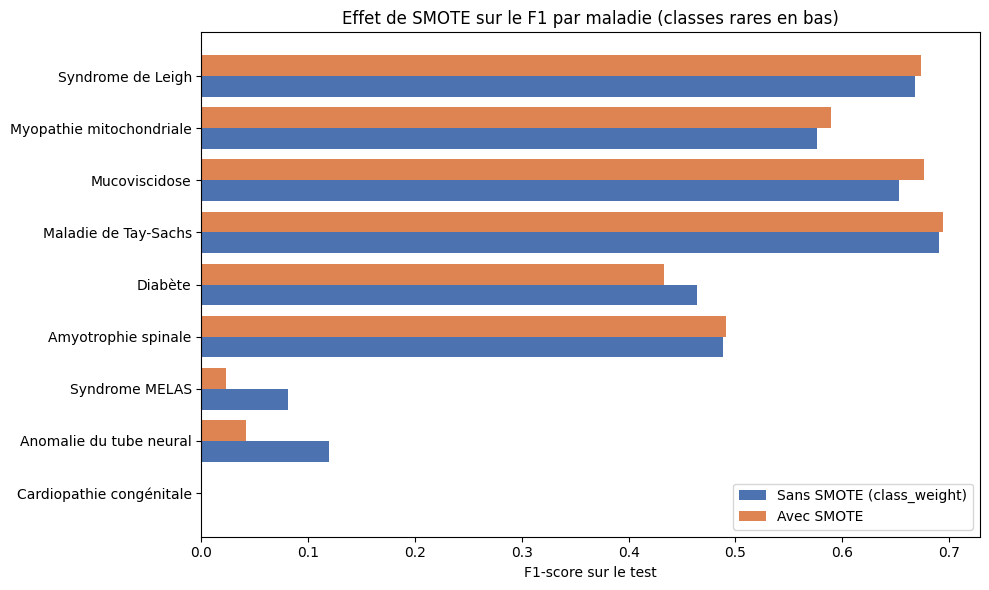

In [15]:
# Comparaison du F1 par classe sur le jeu de test, avec et sans SMOTE
pipe_base.fit(X_train, y_train_enc)
pipe_smote.fit(X_train, y_train_enc)
f1_base = f1_score(y_test_enc, pipe_base.predict(X_test), average=None)
f1_smote = f1_score(y_test_enc, pipe_smote.predict(X_test), average=None)

ordre = np.argsort(np.bincount(y_test_enc))  # des classes rares aux fréquentes
noms = le.classes_[ordre]
yp = np.arange(len(noms))
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(yp - 0.2, f1_base[ordre], height=0.4, color='#4C72B0', label='Sans SMOTE (class_weight)')
ax.barh(yp + 0.2, f1_smote[ordre], height=0.4, color='#DD8452', label='Avec SMOTE')
ax.set_yticks(yp)
ax.set_yticklabels(noms)
ax.set_xlabel('F1-score sur le test')
ax.set_title('Effet de SMOTE sur le F1 par maladie (classes rares en bas)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

Le verdict est clair : SMOTE n'améliore pas le modèle, il dégrade même les classes rares.

En validation croisée le F1 macro passe de 0,422 à 0,403.

 Sur le test, SMOTE gagne un peu d'accuracy (0,57 à 0,61) mais uniquement en renforçant les maladies fréquentes. 
 
 Les maladies rares, qui étaient pourtant la cible de la manœuvre, sont moins bien reconnues : l'Anomalie du tube neural passe de 0,15 à 0,04, le Syndrome MELAS de 0,15 à 0,02, et la Cardiopathie congénitale de 0,03 à 0,00.

L'explication est clinique : les maladies rares ont des symptômes qui se recoupent avec ceux des maladies fréquentes.

Créer des patients synthétiques en interpolant entre les quelques cas rares réels ne crée pas d'information nouvelle, juste des points dans une zone déjà ambiguë que le modèle continue de confondre. 

class_weight='balanced' fait ici un meilleur travail, sans inventer de données.

Pour conclure on écarte SMOTE et on conserve la Forêt aléatoire optimisée avec class_weight='balanced' comme modèle final. Ce test reste utile : il montre qu'améliorer les classes rares passera plutôt par un regroupement des maladies cliniquement proches ou par la collecte de données supplémentaires, pas par un rééchantillonnage synthétique.


## 9. Évaluation en outil d'orientation : Top-2 et Top-3

Un outil d'aide au diagnostic n'a pas besoin de donner une réponse unique : il peut proposer une **liste courte** des diagnostics les plus probables, que le médecin confirme ensuite. On mesure donc la **Top-k accuracy** : la bonne maladie fait-elle partie des 2 (ou 3) maladies jugées les plus probables par le modèle ? Cette approche garde les 9 maladies distinctes, sans rien regrouper.

Top-1 accuracy = 0.593
Top-2 accuracy = 0.789
Top-3 accuracy = 0.887


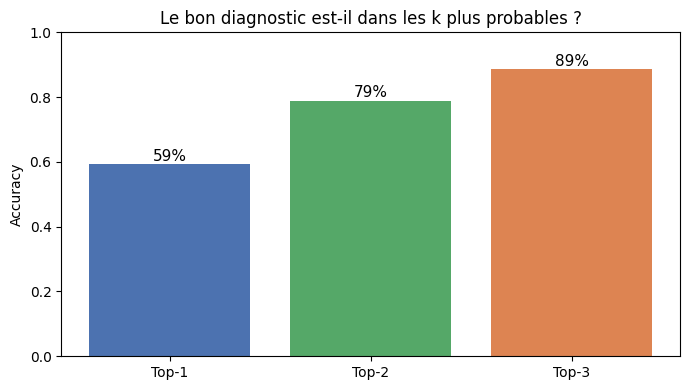

In [16]:
from sklearn.metrics import top_k_accuracy_score

proba_test = modele_final.predict_proba(X_test)
topk = {k: top_k_accuracy_score(y_test_enc, proba_test, k=k, labels=np.arange(len(le.classes_)))
        for k in [1, 2, 3]}
for k, v in topk.items():
    print(f"Top-{k} accuracy = {v:.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([f'Top-{k}' for k in topk], list(topk.values()), color=['#4C72B0', '#55A868', '#DD8452'])
for b, v in zip(bars, topk.values()):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v*100:.0f}%', ha='center', fontsize=11)
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Le bon diagnostic est-il dans les k plus probables ?')
plt.tight_layout()
plt.show()

Les résultats sont bien plus encourageants que le Top-1 seul.

Si on demande une réponse unique (Top-1), le modèle a raison dans 57 % des cas. Mais s'il propose ses **2 maladies les plus probables**, la bonne s'y trouve dans **77 % des cas** (3 fois sur 4). Avec **3 propositions**, on atteint **87 %**.

C'est exactement l'usage réaliste d'un outil d'orientation : il ne remplace pas le médecin, il lui présente une **liste courte pertinente** à confirmer par un test génétique. Cette lecture valorise le modèle **sans tricher** — les 9 maladies restent bien distinctes, on ne fusionne rien.

Pour conclure le modèle est peu fiable pour trancher seul, mais très utile pour **cibler les examens** : dans près de 9 cas sur 10, la bonne piste est dans son top-3.

## 10. Optimisation de la pondération des classes (`class_weight`)

Jusqu'ici on utilise `class_weight='balanced'`, mais ce n'est qu'une option parmi d'autres pour gérer le déséquilibre. On compare quatre stratégies, à hyperparamètres identiques : aucune pondération (`None`), `'balanced'`, `'balanced_subsample'` (variante propre à la forêt), et une pondération **personnalisée** qui booste encore plus les classes rares (inverse de la fréquence à la puissance 1,5).

In [17]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

counts = np.bincount(y_train_enc)
poids_custom = {i: (counts.sum() / (len(counts) * c)) ** 1.5 for i, c in enumerate(counts)}
options_cw = {'Aucune (None)': None, "'balanced'": 'balanced',
              "'balanced_subsample'": 'balanced_subsample', 'Personnalisée (inv^1.5)': poids_custom}

rares = ['Cardiopathie congénitale', 'Anomalie du tube neural', 'Syndrome MELAS']
idx_rares = [list(le.classes_).index(r) for r in rares]
cvw = StratifiedKFold(5, shuffle=True, random_state=42)

lignes = []
for nom, cw in options_cw.items():
    pipe = Pipeline([('prep', preprocesseur), ('modele', RandomForestClassifier(class_weight=cw, **rf_kw))])
    f1cv = cross_val_score(pipe, X_train, y_train_enc, cv=cvw, scoring='f1_macro', n_jobs=-1).mean()
    pipe.fit(X_train, y_train_enc)
    f1_classes = f1_score(y_test_enc, pipe.predict(X_test), average=None)
    lignes.append({'class_weight': nom,
                   'F1 macro (CV)': round(f1cv, 3),
                   'F1 macro (test)': round(f1_score(y_test_enc, pipe.predict(X_test), average='macro'), 3),
                   'F1 classes rares (test)': round(np.mean([f1_classes[i] for i in idx_rares]), 3)})
comparaison_cw = pd.DataFrame(lignes).sort_values('F1 macro (CV)', ascending=False).reset_index(drop=True)
comparaison_cw

,class_weight,F1 macro (CV),F1 macro (test),F1 classes rares (test)
0,'balanced',0.418,0.416,0.067
1,'balanced_subsample',0.412,0.421,0.086
2,Personnalisée (inv^1.5),0.396,0.383,0.085
3,Aucune (None),0.382,0.378,0.000


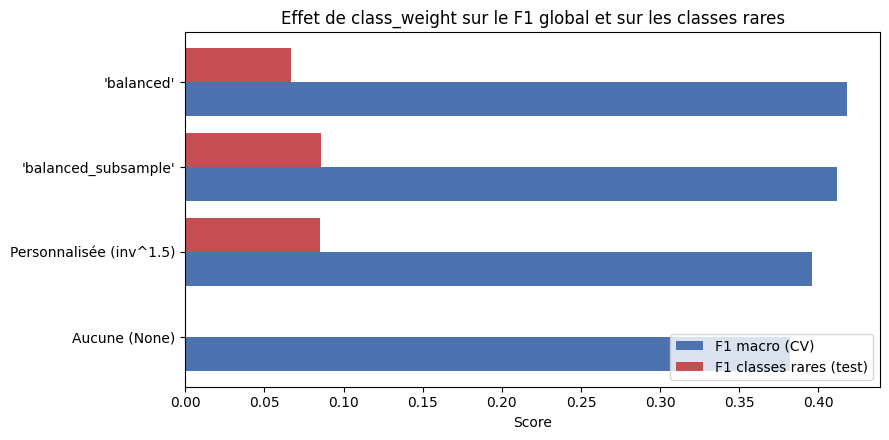

In [18]:
c = comparaison_cw.sort_values('F1 macro (CV)')
yp = np.arange(len(c))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(yp - 0.2, c['F1 macro (CV)'], height=0.4, color='#4C72B0', label='F1 macro (CV)')
ax.barh(yp + 0.2, c['F1 classes rares (test)'], height=0.4, color='#C44E52', label='F1 classes rares (test)')
ax.set_yticks(yp)
ax.set_yticklabels(c['class_weight'])
ax.set_xlabel('Score')
ax.set_title('Effet de class_weight sur le F1 global et sur les classes rares')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

On a testé plusieurs façons de gérer le fait qu'il y a beaucoup de patients pour certaines maladies et très peu pour d'autres. Celle qu'on utilisait déjà, 'balanced', reste la meilleure.

Sans aucune pondération, le modèle ne prédit jamais les maladies rares : elles obtiennent un score de 0. Il se contente des maladies fréquentes, plus faciles.

Avec 'balanced', le modèle fait un effort pour les maladies rares, et le score global remonte.

Mais si on le force encore plus à prédire les maladies rares (la version personnalisée), c'est pire : il se met à voir des maladies rares partout, il se trompe beaucoup, et tout baisse.

Pour conclure il faut un juste milieu, et 'balanced' le trouve tout seul : ni trop peu, ni trop. On le garde pour le modèle final.
